In [1]:
from models import ta_transform
import trading.model_tools as mt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%pip install ipympl
%matplotlib ipympl


data = mt.fetch_data(
    symbols=["SOL-USDT", "BTC-USDT"],
    days=730,
    interval="1h",
    age_days=0,
    data_source="binance",
    cache_expiry_hours=-1,
    verbose=True,
)

features = ta_transform(data, add_ticker="BTC-USDT")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


FETCHING DATASET(S) SOL-USDT, BTC-USDT; 730d of 1h

USING CACHE /home/fluidize/.local/share/market_data/SOL-USDT_BTC-USDT_730_1h_0_binance.csv (3.02 MB 17533 bars)

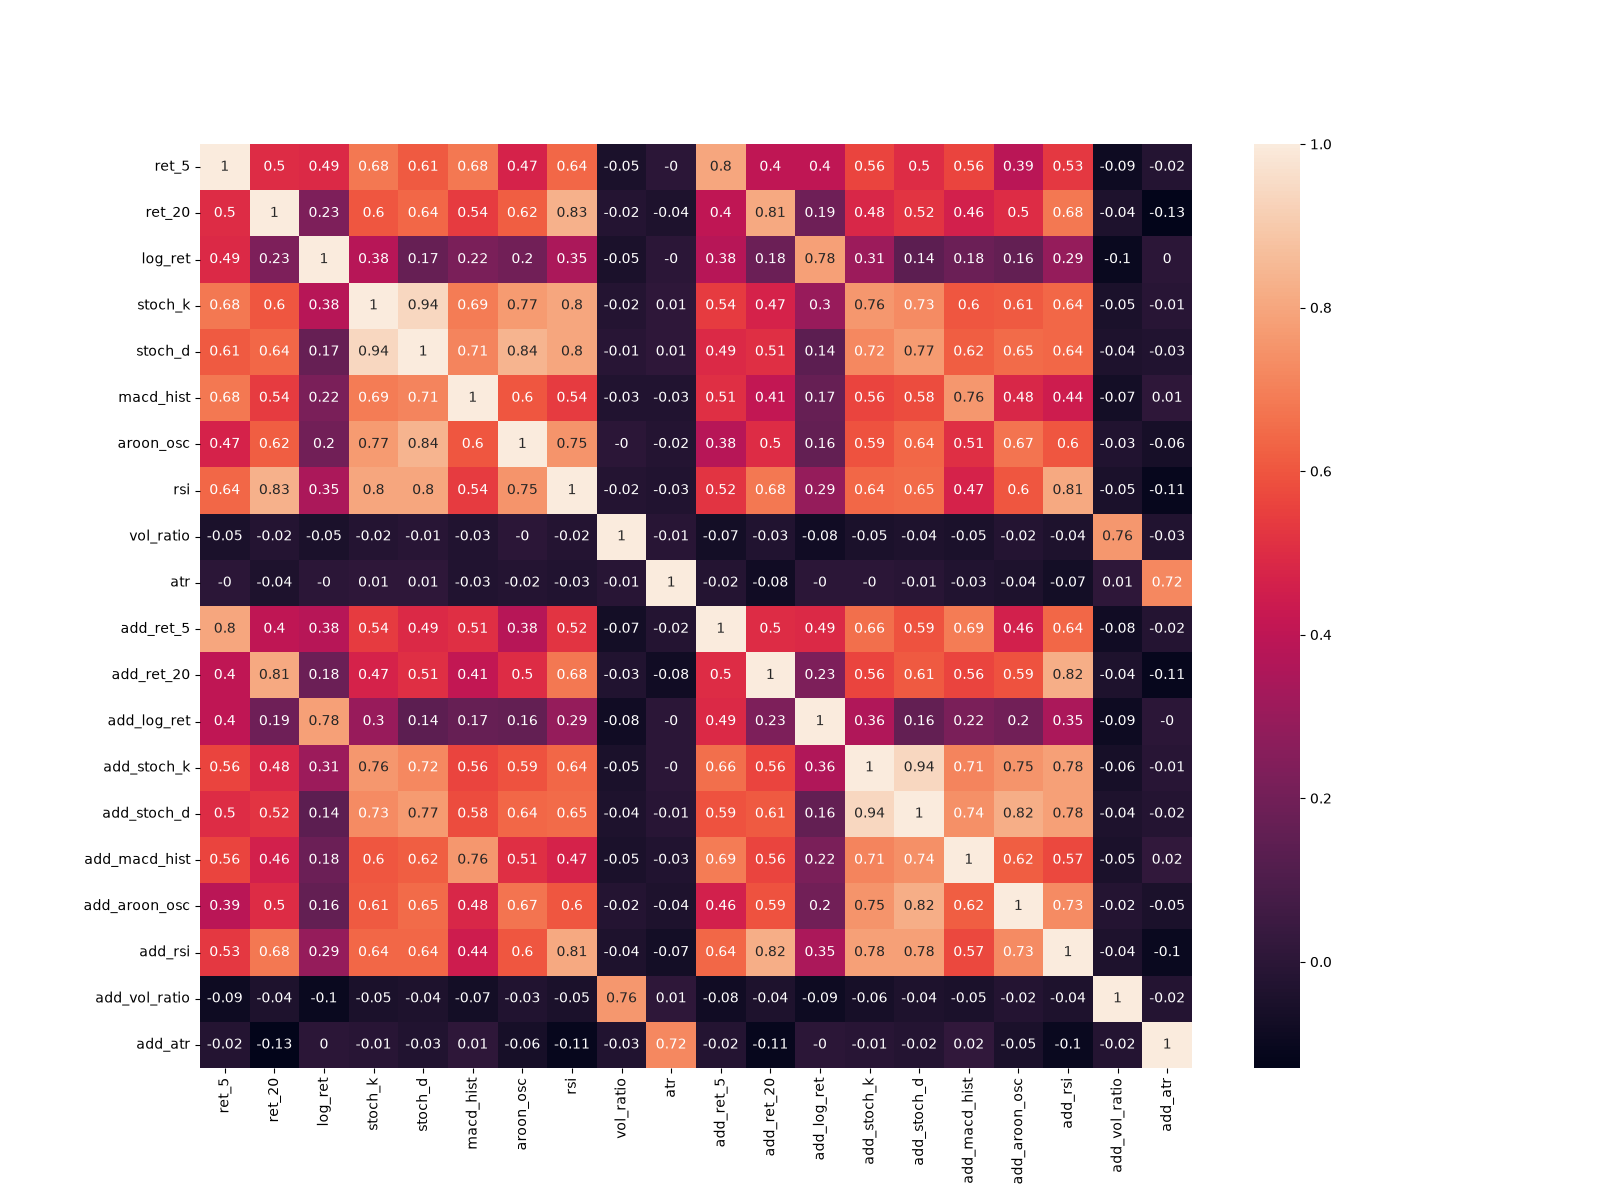

In [2]:
corr_matrix = np.round(features.corr(), 2)
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True)
plt.show()

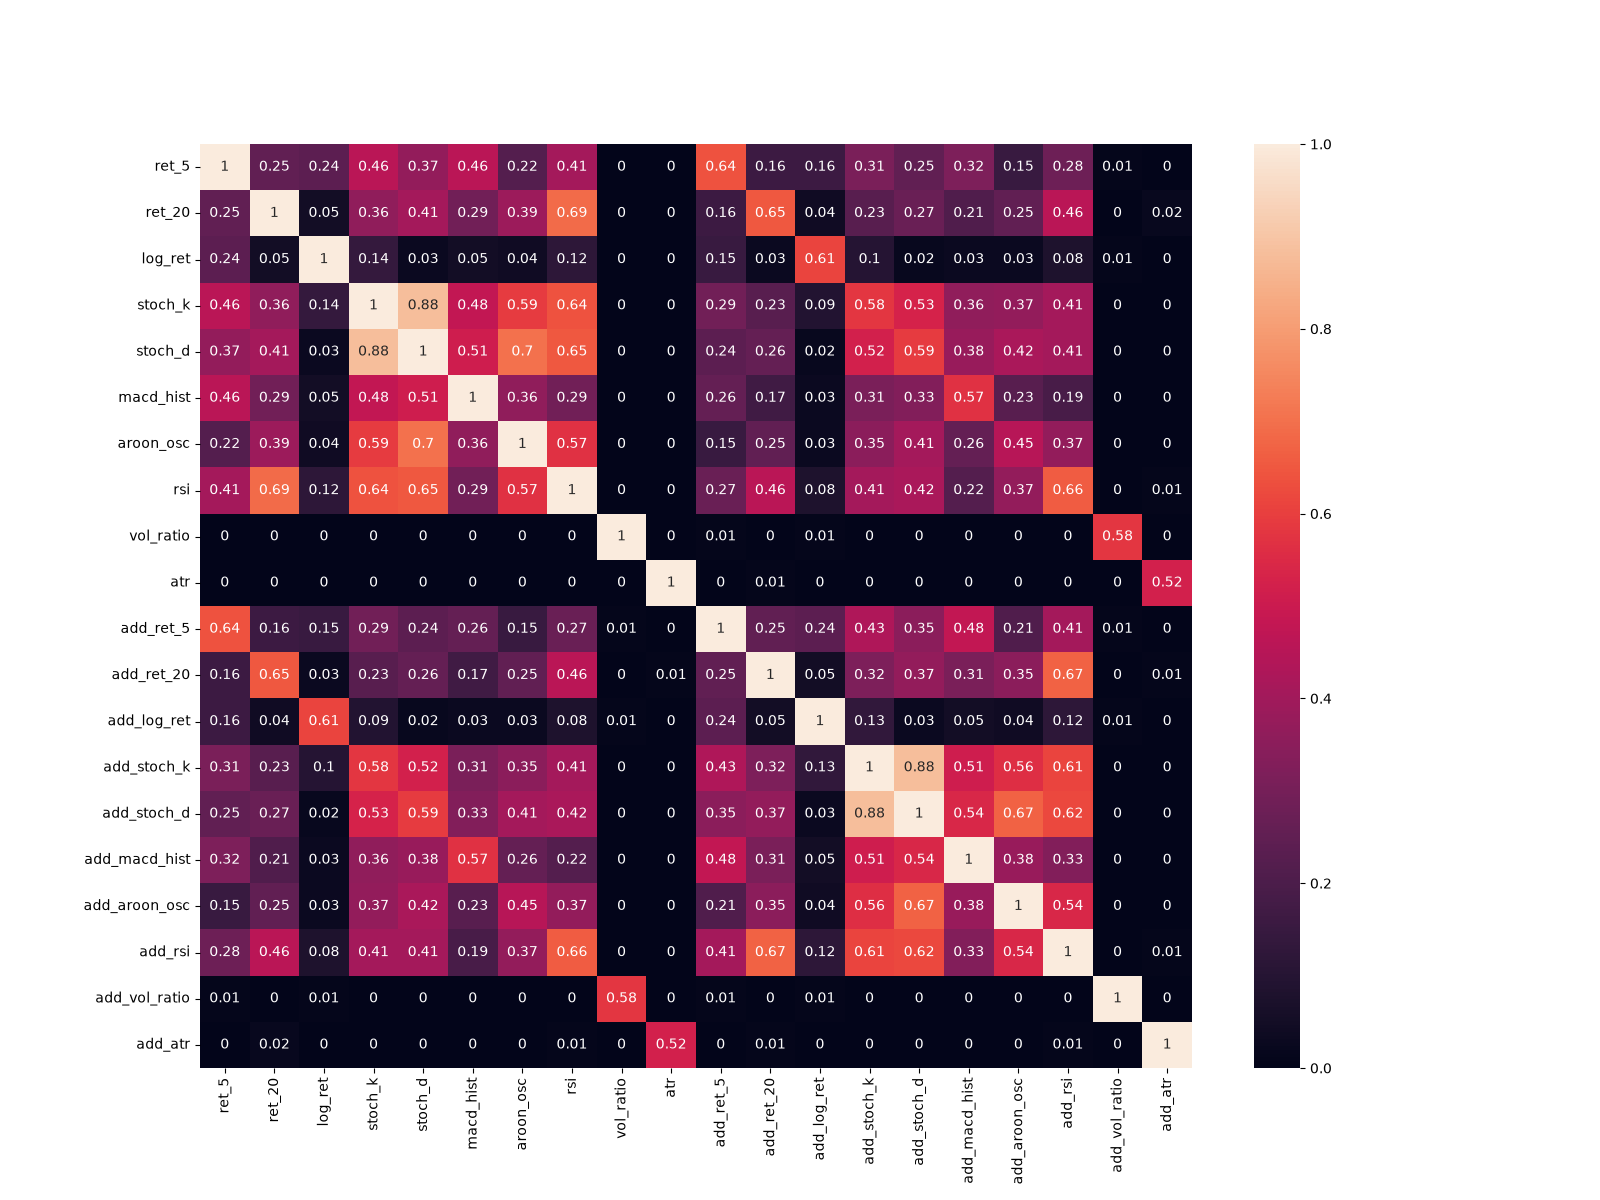

In [3]:
r2_matrix = np.round(np.pow(features.corr(), 2), 2)
plt.figure(figsize=(16,12))
sns.heatmap(r2_matrix, annot=True)
plt.show()

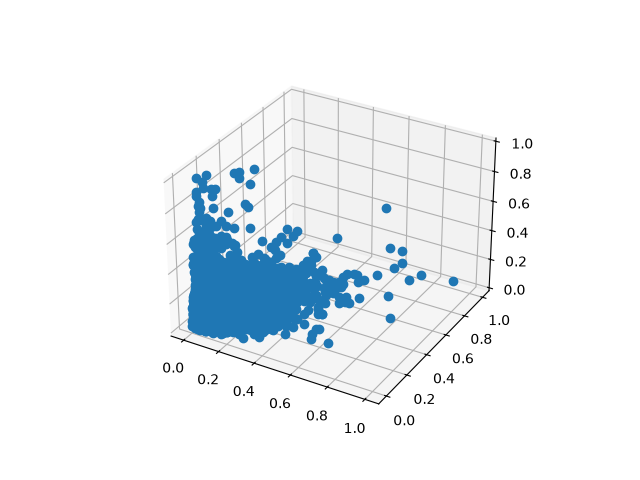

In [4]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

plt.plot(features["vol_ratio"], features["add_vol_ratio"], features["atr"], 'o')